# Analysing Permissions and Trackers of the mHealth Apps

This notebook analyzes permission and tracker usage across countries, regions, and app categories.

## Setup and shared utilities

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

# Paths
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Region / country mappings
REGION_MAP = {
    "us": "North America", "ca": "North America", "gl":"North America",
    "mx": "Latin America", "br": "Latin America", "ar": "Latin America", 
    "cl": "Latin America",
    "de": "Europe", "fr": "Europe", "gb": "Europe", 
    "pl": "Europe",
    "tr": "Middle East", "il": "Middle East", "sa": "Middle East", 
    "ae": "Middle East",
    "in": "Asia", "jp": "Asia", "sg": "Asia", 
    "kr": "Asia",
    "za": "Africa", "mz": "Africa", "ng": "Africa", 
    "ke": "Africa",
    "au": "Oceania", "nz": "Oceania", 
    "pg": "Oceania"
}

COUNTRY_LABEL_MAP = {
    "us": "United States", "ca": "Canada", "gl":"Greenland",
    "mx": "Mexico", "br": "Brazil", "ar": "Argentina",
    "cl": "Chile",
    "de": "Germany", "fr": "France", "gb": "Great Britain",
    "pl": "Poland",
    "tr": "Turkey", "il": "Israel", "sa": "Saudi Arabia",
    "ae": "United Arab Emirates",
    "in": "India", "jp": "Japan", "sg": "Singapore",
    "kr": "South Korea",
    "za": "South Africa", "mz": "Mozambique", "ng": "Nigeria",
    "ke": "Kenya",
    "au": "Australia", "nz": "New Zealand",
    "pg": "Papua New Guinea"
}

mhealth_apps = pd.read_csv("../data/mhealth_apps_metrics.csv")

mhealth_apps["country"] = mhealth_apps["country"].astype(str).str.strip().str.lower()
mhealth_apps["region"] = mhealth_apps["country"].map(REGION_MAP)
mhealth_apps["country_label"] = mhealth_apps["country"].map(COUNTRY_LABEL_MAP)

for col in ["downloads_int", "num_permissions", "num_dangerous_permissions", "num_trackers"]:
    if col in mhealth_apps.columns:
        mhealth_apps[col] = pd.to_numeric(mhealth_apps[col], errors="coerce")

# Keep one row per app for app-level category analyses
unique_df = mhealth_apps.drop_duplicates(subset="app_id").copy()
regions = sorted(mhealth_apps["region"].dropna().unique())

# Helpers
def split_items(value):
    if pd.isna(value):
        return []
    return [
        x.strip() for x in re.split(r",\s*", str(value))
        if x.strip() and x.strip().lower() != "nan"
    ]

def extract_unique_item(series):
    unique_items = set()
    for items in series.dropna():
        unique_items.update(split_items(items))
    return unique_items

def count_items(series):
    item_counts = {}
    for items in series.dropna():
        for item in split_items(items):
            item_counts[item] = item_counts.get(item, 0) + 1
    return item_counts

def count_item_frequency(series):
    return count_items(series)

def clean_permission(permission):
    return str(permission).split(".")[-1].replace("!", "").strip()

def clean_permission_counts(permission_counts):
    cleaned = {}
    for perm, count in permission_counts.items():
        cleaned_name = clean_permission(perm)
        cleaned[cleaned_name] = cleaned.get(cleaned_name, 0) + count
    return cleaned

def count_permission_list(series):
    counts = []
    for items in series.dropna():
        counts.append(len(set(split_items(items))))
    return counts

def count_unique_items_per_app(series):
    return count_permission_list(series)


/var/folders/1q/3rt9l52n0kx8ddr5w0rszmvr0000gn/T/ipykernel_10524/46810981.py:44: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  mhealth_apps = pd.read_csv("../data/mhealth_apps_metrics.csv")


## Permissions analysis

This section summarizes permissions and dangerous permissions at the region, country, and category levels, then visualizes their geographic distribution.

In [2]:
# 1) Unique permissions
all_permissions = extract_unique_item(mhealth_apps["permissions"])
all_dangerous_permissions = extract_unique_item(mhealth_apps["dangerous_permissions"])

print("\nTotal Unique Permissions (Global)")
print("=" * 70)
print(f"Total unique permissions: {len(all_permissions)}")
print(f"Total unique dangerous permissions: {len(all_dangerous_permissions)}")


region_permission_sets = {}
region_dangerous_permission_sets = {}

for region in sorted(mhealth_apps["region"].dropna().unique()):
    region_df = mhealth_apps[mhealth_apps["region"] == region]
    region_permission_sets[region] = extract_unique_item(region_df["permissions"])
    region_dangerous_permission_sets[region] = extract_unique_item(region_df["dangerous_permissions"])

print("=" * 70)

print("Unique Permissions by Region")
print("=" * 70)
for region in region_permission_sets:
    print(f"{region:<20} | All permissions: {len(region_permission_sets[region]):<5} | Dangerous permissions: {len(region_dangerous_permission_sets[region]):<5}")




Total Unique Permissions (Global)
Total unique permissions: 1301
Total unique dangerous permissions: 49
Unique Permissions by Region
Africa               | All permissions: 1276  | Dangerous permissions: 49   
Asia                 | All permissions: 1276  | Dangerous permissions: 49   
Europe               | All permissions: 1283  | Dangerous permissions: 49   
Latin America        | All permissions: 1295  | Dangerous permissions: 49   
Middle East          | All permissions: 1288  | Dangerous permissions: 49   
North America        | All permissions: 1285  | Dangerous permissions: 49   
Oceania              | All permissions: 1287  | Dangerous permissions: 49   


In [3]:
# 2) Unique permissions by country
country_permission_sets = {}
country_dangerous_permission_sets = {}

for country_code in sorted(mhealth_apps["country"].dropna().unique()):
    country_df = mhealth_apps[mhealth_apps["country"] == country_code]
    country_name = COUNTRY_LABEL_MAP.get(country_code, country_code.upper())

    country_permission_sets[country_code] = extract_unique_item(country_df["permissions"])
    country_dangerous_permission_sets[country_code] = extract_unique_item(country_df["dangerous_permissions"])

print("\n\nUnique Permissions by Country")
print("=" * 70)
for country_code in country_permission_sets:
    country_name = COUNTRY_LABEL_MAP.get(country_code, country_code.upper())
    print(f"{country_name:<20} | All permissions: {len(country_permission_sets[country_code]):<5} | Dangerous permissions: {len(country_dangerous_permission_sets[country_code]):<5}")





Unique Permissions by Country
United Arab Emirates | All permissions: 1251  | Dangerous permissions: 49   
Argentina            | All permissions: 1250  | Dangerous permissions: 49   
Australia            | All permissions: 1287  | Dangerous permissions: 49   
Brazil               | All permissions: 1295  | Dangerous permissions: 49   
Canada               | All permissions: 1283  | Dangerous permissions: 49   
Chile                | All permissions: 1245  | Dangerous permissions: 49   
Germany              | All permissions: 1281  | Dangerous permissions: 49   
France               | All permissions: 1280  | Dangerous permissions: 49   
Great Britain        | All permissions: 1251  | Dangerous permissions: 49   
Greenland            | All permissions: 1247  | Dangerous permissions: 49   
Israel               | All permissions: 1286  | Dangerous permissions: 49   
India                | All permissions: 1256  | Dangerous permissions: 49   
Japan                | All permissions: 1269

In [4]:
# 3) Category-level dangerous permission statistics
unique_df = mhealth_apps.drop_duplicates(subset="app_id").copy()

def calculate_category_stats(data, column_name):
    stats = []
    grouped = data.groupby("categories", dropna=False)

    for category, group in grouped:
        permission_counts = count_permission_list(group[column_name])
        stats.append({
            "category": category,
            "mean_permissions": pd.Series(permission_counts).mean(),
            "max_permissions": pd.Series(permission_counts).max(),
            "median_permissions": pd.Series(permission_counts).median(),
            "unique_permissions": len(extract_unique_item(group[column_name]))
        })

    return pd.DataFrame(stats)

category_stats = calculate_category_stats(unique_df, "dangerous_permissions")
category_stats_sorted = category_stats.sort_values(by="unique_permissions", ascending=False)

top_5_categories = category_stats_sorted.head(5)
others = category_stats_sorted.iloc[5:]

others_unique_permissions = set()
for _, row in others.iterrows():
    cat = row["category"]
    cat_values = unique_df.loc[unique_df["categories"] == cat, "dangerous_permissions"]
    others_unique_permissions.update(extract_unique_item(cat_values))

others_summary = {
    "category": "Others",
    "mean_permissions": others["mean_permissions"].mean() if len(others) > 0 else 0,
    "max_permissions": others["max_permissions"].max() if len(others) > 0 else 0,
    "median_permissions": others["median_permissions"].median() if len(others) > 0 else 0,
    "unique_permissions": len(others_unique_permissions)
}

final_category_stats = pd.DataFrame([*top_5_categories.to_dict(orient="records"), others_summary])

print("\n\nCategory-level Dangerous Permission Statistics")
print("=" * 70)
final_category_stats



Category-level Dangerous Permission Statistics


,category,mean_permissions,max_permissions,median_permissions,unique_permissions
0,Health & Fitness,4.326693,24,4.0,49
1,Medical,4.131429,15,3.0,26
2,Lifestyle,3.296296,9,3.0,21
3,Parenting,4.680000,13,3.0,18
4,Education,3.545455,9,3.0,18
5,Others,4.245455,8,3.5,14


In [5]:
# 4) Top dangerous permissions overall
# Use unique_df (one row per app) rather than mhealth_apps (one row per
# app-country pair, ~25 rows/app): dangerous_permissions is identical
# across all of an app's country rows, so counting over mhealth_apps
# inflated every count by roughly the average number of countries per app
# (~25x), since the same app's permission set was counted once per country
# it happened to be observed in.
overall_dangerous_counts = count_items(unique_df["dangerous_permissions"])
overall_dangerous_counts_clean = clean_permission_counts(overall_dangerous_counts)

sorted_permissions = sorted(overall_dangerous_counts_clean.items(), key=lambda x: x[1], reverse=True)
top_10_permissions = sorted_permissions[:10]

print("\n\nTop 10 Dangerous Permissions Overall")
print("=" * 70)
for perm, value in top_10_permissions:
    print(f"{perm:<35} {value}")




Top 10 Dangerous Permissions Overall
WRITE_EXTERNAL_STORAGE              546
READ_EXTERNAL_STORAGE               516
WRITE_SETTINGS                      371
CAMERA                              347
RECORD_AUDIO                        253
ACCESS_COARSE_LOCATION              173
ACCESS_FINE_LOCATION                165
READ_PHONE_STATE                    152
SYSTEM_ALERT_WINDOW                 141
ACTIVITY_RECOGNITION                96


In [6]:
# 5) Top dangerous permissions by region

# Ensure regions is defined
regions = sorted(mhealth_apps["region"].dropna().unique())

region_dangerous_counts_clean = {}

for region in regions:
    region_df = mhealth_apps[mhealth_apps["region"] == region].drop_duplicates(subset="app_id")
    region_counts = count_items(region_df["dangerous_permissions"])
    region_dangerous_counts_clean[region] = clean_permission_counts(region_counts)

print("\n\nTop Dangerous Permissions by Region")
print("=" * 70)
for region in regions:
    print(f"\n{region}:")
    region_top = sorted(
        region_dangerous_counts_clean[region].items(),
        key=lambda x: x[1],
        reverse=True
    )[:10]

    for perm, value in region_top:
        print(f"{perm:<35} {value}")



Top Dangerous Permissions by Region

Africa:
WRITE_EXTERNAL_STORAGE              533
READ_EXTERNAL_STORAGE               504
WRITE_SETTINGS                      365
CAMERA                              338
RECORD_AUDIO                        245
ACCESS_COARSE_LOCATION              164
ACCESS_FINE_LOCATION                156
READ_PHONE_STATE                    147
SYSTEM_ALERT_WINDOW                 138
ACTIVITY_RECOGNITION                94

Asia:
WRITE_EXTERNAL_STORAGE              534
READ_EXTERNAL_STORAGE               503
WRITE_SETTINGS                      367
CAMERA                              339
RECORD_AUDIO                        243
ACCESS_COARSE_LOCATION              167
ACCESS_FINE_LOCATION                159
READ_PHONE_STATE                    145
SYSTEM_ALERT_WINDOW                 136
ACTIVITY_RECOGNITION                93

Europe:
WRITE_EXTERNAL_STORAGE              535
READ_EXTERNAL_STORAGE               504
WRITE_SETTINGS                      367
CAMERA             

In [7]:
# 6) Top dangerous permissions by country
country_dangerous_counts_clean = {}

for country_code in sorted(mhealth_apps["country"].dropna().unique()):
    country_df = mhealth_apps[mhealth_apps["country"] == country_code]
    country_counts = count_items(country_df["dangerous_permissions"])
    country_dangerous_counts_clean[country_code] = clean_permission_counts(country_counts)

print("\n\nTop Dangerous Permissions by Country")
print("=" * 70)
for country_code in sorted(country_dangerous_counts_clean.keys()):
    country_name = COUNTRY_LABEL_MAP.get(country_code, country_code.upper())
    print(f"\n{country_name}:")
    country_top = sorted(country_dangerous_counts_clean[country_code].items(), key=lambda x: x[1], reverse=True)[:10]
    for perm, value in country_top:
        print(f"{perm:<35} {value}")





Top Dangerous Permissions by Country

United Arab Emirates:
WRITE_EXTERNAL_STORAGE              522
READ_EXTERNAL_STORAGE               492
WRITE_SETTINGS                      357
CAMERA                              331
RECORD_AUDIO                        238
ACCESS_COARSE_LOCATION              160
ACCESS_FINE_LOCATION                153
READ_PHONE_STATE                    140
SYSTEM_ALERT_WINDOW                 130
ACTIVITY_RECOGNITION                91

Argentina:
WRITE_EXTERNAL_STORAGE              519
READ_EXTERNAL_STORAGE               490
WRITE_SETTINGS                      351
CAMERA                              328
RECORD_AUDIO                        239
ACCESS_COARSE_LOCATION              159
ACCESS_FINE_LOCATION                150
READ_PHONE_STATE                    144
SYSTEM_ALERT_WINDOW                 132
ACTIVITY_RECOGNITION                91

Australia:
WRITE_EXTERNAL_STORAGE              538
READ_EXTERNAL_STORAGE               508
WRITE_SETTINGS                      

In [8]:
# 7) Region contributions for overall top-10 dangerous permissions
data = {"Permission": []}
for region in regions:
    data[region] = []

for perm, total_count in top_10_permissions:
    data["Permission"].append(perm)
    for region in regions:
        region_count = region_dangerous_counts_clean[region].get(perm, 0)
        data[region].append(region_count)

df_stacked = pd.DataFrame(data)

print("\n\nTop 10 Dangerous Permissions with Regional Counts")
print("=" * 70)
df_stacked





Top 10 Dangerous Permissions with Regional Counts


,Permission,Africa,Asia,Europe,Latin America,Middle East,North America,Oceania
0,WRITE_EXTERNAL_STORAGE,533,534,535,544,541,535,538
1,READ_EXTERNAL_STORAGE,504,503,504,514,510,506,508
2,WRITE_SETTINGS,365,367,367,371,367,367,365
3,CAMERA,338,339,339,346,343,339,341
4,RECORD_AUDIO,245,243,244,251,250,244,247
5,ACCESS_COARSE_LOCATION,164,167,166,172,169,166,169
6,ACCESS_FINE_LOCATION,156,159,158,164,161,158,161
7,READ_PHONE_STATE,147,145,145,150,149,145,148
8,SYSTEM_ALERT_WINDOW,138,136,136,140,138,136,137
9,ACTIVITY_RECOGNITION,94,93,93,95,94,93,94


In [9]:
# 8) Country-level matrix for overall top-10 dangerous permissions
country_data = {"Permission": []}
for country_code in sorted(country_dangerous_counts_clean.keys()):
    country_name = COUNTRY_LABEL_MAP.get(country_code, country_code.upper())
    country_data[country_name] = []

for perm, total_count in top_10_permissions:
    country_data["Permission"].append(perm)
    for country_code in sorted(country_dangerous_counts_clean.keys()):
        country_name = COUNTRY_LABEL_MAP.get(country_code, country_code.upper())
        country_count = country_dangerous_counts_clean[country_code].get(perm, 0)
        country_data[country_name].append(country_count)

df_country_permissions = pd.DataFrame(country_data)

print("\n\nTop 10 Dangerous Permissions with Country Counts")
print("=" * 70)
df_country_permissions



Top 10 Dangerous Permissions with Country Counts


,Permission,United Arab Emirates,Argentina,Australia,Brazil,Canada,Chile,Germany,France,Great Britain,...,Mozambique,Nigeria,New Zealand,Papua New Guinea,Poland,Saudi Arabia,Singapore,Turkey,United States,South Africa
0,WRITE_EXTERNAL_STORAGE,522,519,538,544,533,520,533,532,522,...,530,520,527,523,522,521,520,523,528,528
1,READ_EXTERNAL_STORAGE,492,490,508,514,503,490,502,501,490,...,499,489,497,491,491,492,492,495,498,500
2,WRITE_SETTINGS,357,351,365,371,364,352,367,367,358,...,363,355,355,355,355,360,352,355,363,363
3,CAMERA,331,328,341,346,337,329,338,336,327,...,335,328,332,331,329,328,329,332,333,333
4,RECORD_AUDIO,238,239,247,251,243,237,244,243,238,...,244,238,240,238,238,240,241,241,238,242
5,ACCESS_COARSE_LOCATION,160,159,169,172,166,158,165,165,159,...,163,160,162,160,160,161,160,159,163,163
6,ACCESS_FINE_LOCATION,153,150,161,164,158,153,158,157,151,...,156,153,154,153,153,153,153,152,155,155
7,READ_PHONE_STATE,140,144,148,150,144,140,144,144,139,...,145,138,140,140,140,141,142,141,142,143
8,SYSTEM_ALERT_WINDOW,130,132,137,140,135,127,136,135,132,...,136,129,133,129,129,135,131,133,133,134
9,ACTIVITY_RECOGNITION,91,91,94,95,93,91,93,92,88,...,94,91,91,91,91,91,91,91,93,91


## Tracker analysis

This section summarizes tracker prevalence and tracker diversity across app categories.

In [10]:
apps_tracker = unique_df[
    unique_df["trackers"].notna()
    & (unique_df["trackers"].astype(str).str.strip() != "")
]
print(f"Number of apps with trackers: {len(apps_tracker)} ({len(apps_tracker) / len(unique_df) * 100:.2f}%)")

trackers_counts = count_item_frequency(unique_df["trackers"])
sorted_trackers = sorted(trackers_counts.items(), key=lambda item: item[1], reverse=True)

# Total unique trackers (global)
all_trackers = extract_unique_item(unique_df["trackers"])

print("=" * 70)
print("\nTotal Trackers (Global)")
print(f"Total unique trackers: {len(all_trackers)}")
print()

print("=" * 70)

print("Top 10 most frequent trackers:")
for key, value in sorted_trackers[:10]:
    print(f"{key:<80} {value}")

# Category-level tracker statistics
def calculate_tracker_category_stats(data, column_name="trackers"):
    stats = []
    grouped = data.groupby("categories")

    for category, group in grouped:
        tracker_counts = count_unique_items_per_app(group[column_name])
        stats.append({
            "category": category,
            "num_apps": len(group),
            "mean_trackers": pd.Series(tracker_counts).mean() if tracker_counts else 0,
            "max_trackers": pd.Series(tracker_counts).max() if tracker_counts else 0,
            "median_trackers": pd.Series(tracker_counts).median() if tracker_counts else 0,
            "unique_trackers": len(extract_unique_item(group[column_name])),
        })

    return pd.DataFrame(stats)

category_tracker_stats = calculate_tracker_category_stats(unique_df, "trackers")
category_tracker_stats_sorted = category_tracker_stats.sort_values(by="unique_trackers", ascending=False)

top_5_categories = category_tracker_stats_sorted.head(5)
others = category_tracker_stats_sorted.iloc[5:]

others_unique_trackers = set()
for _, row in others.iterrows():
    others_unique_trackers.update(
        extract_unique_item(unique_df[unique_df["categories"] == row["category"]]["trackers"])
    )

others_summary = {
    "category": "Others",
    "num_apps": others["num_apps"].sum(),
    "mean_trackers": others["mean_trackers"].mean() if not others.empty else 0,
    "max_trackers": others["max_trackers"].max() if not others.empty else 0,
    "median_trackers": others["median_trackers"].median() if not others.empty else 0,
    "unique_trackers": len(others_unique_trackers),
}

final_category_tracker_stats = pd.DataFrame(
    [*top_5_categories.to_dict(orient="records"), others_summary]
)

print("Category-level tracker summary:")
final_category_tracker_stats



Number of apps with trackers: 844 (90.66%)

Total Trackers (Global)
Total unique trackers: 136

Top 10 most frequent trackers:
Google Firebase Analytics                                                        738
Google CrashLytics                                                               584
Facebook Login                                                                   323
Facebook Share                                                                   299
Google AdMob                                                                     286
Facebook Analytics                                                               240
AppsFlyer                                                                        162
Sentry                                                                           128
Facebook Ads                                                                     117
IAB Open Measurement                                                             106
Category-level tracker 

,category,num_apps,mean_trackers,max_trackers,median_trackers,unique_trackers
0,Health & Fitness,615,5.737676,35,5.00,120
1,Medical,209,4.602210,19,4.00,84
2,Parenting,28,8.607143,32,7.00,60
3,Lifestyle,34,6.689655,33,5.00,55
4,Education,28,5.652174,32,3.00,46
5,Others,17,5.852273,28,5.25,40


## Combined category summary

The next cell combines permissions, dangerous permissions, and trackers into one category-level summary table.

In [11]:
def calculate_category_stats(data):
    stats = []
    grouped = data.groupby("categories")

    for category, group in grouped:
        stats.append({
            "category": category,
            "num_apps": len(group),
            "unique_permissions": len(extract_unique_item(group["permissions"])),
            "unique_dangerous_permissions": len(extract_unique_item(group["dangerous_permissions"])),
            "unique_trackers": len(extract_unique_item(group["trackers"])),
        })

    return pd.DataFrame(stats)

category_stats = calculate_category_stats(unique_df)
category_stats_sorted = category_stats.sort_values(by="num_apps", ascending=False)

top_categories = category_stats_sorted.head(5)
other_categories = category_stats_sorted.iloc[5:]

others_unique_permissions = set()
others_unique_dangerous_permissions = set()
others_unique_trackers = set()

for _, row in other_categories.iterrows():
    category_name = row["category"]
    category_subset = unique_df[unique_df["categories"] == category_name]
    others_unique_permissions.update(extract_unique_item(category_subset["permissions"]))
    others_unique_dangerous_permissions.update(extract_unique_item(category_subset["dangerous_permissions"]))
    others_unique_trackers.update(extract_unique_item(category_subset["trackers"]))

others_summary_all = {
    "category": "Others",
    "num_apps": other_categories["num_apps"].sum(),
    "unique_permissions": len(others_unique_permissions),
    "unique_dangerous_permissions": len(others_unique_dangerous_permissions),
    "unique_trackers": len(others_unique_trackers),
}

category_stats_final = pd.DataFrame([*top_categories.to_dict(orient="records"), others_summary_all])

print("Final category summary:")
category_stats_final



Final category summary:


,category,num_apps,unique_permissions,unique_dangerous_permissions,unique_trackers
0,Health & Fitness,615,988,49,120
1,Medical,209,408,26,84
2,Lifestyle,34,131,21,55
3,Parenting,28,112,18,60
4,Education,28,108,18,46
5,Others,17,82,14,40


## Comparative visualization

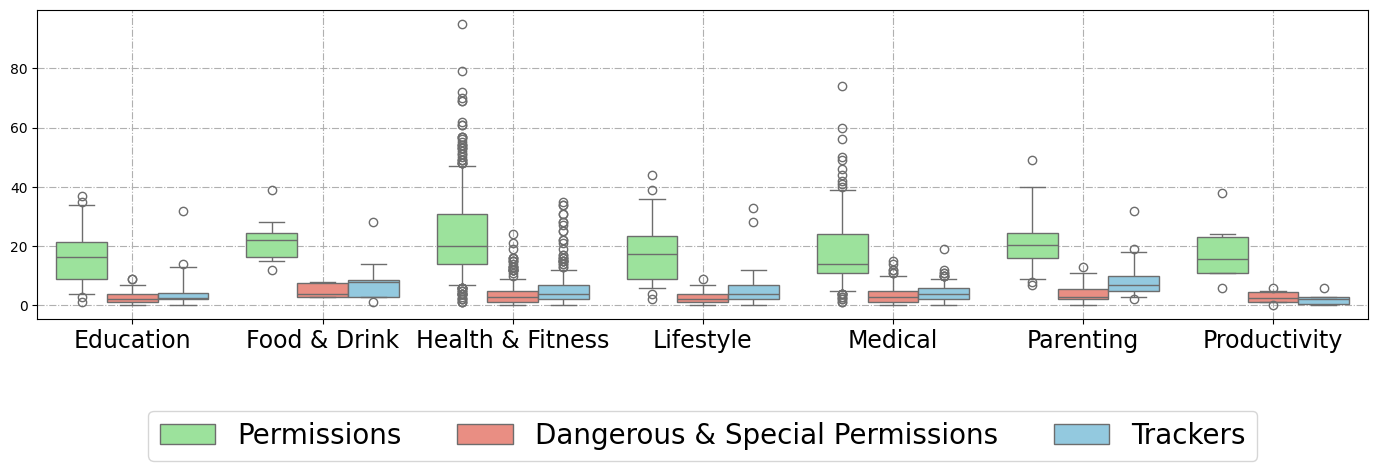

In [12]:
plot_df = unique_df.copy()

# Ensure clean category values
plot_df["categories"] = plot_df["categories"].astype(str).str.strip()

# Use ALL categories (no merging)
category_order = sorted(plot_df["categories"].dropna().unique())

# Reshape data
melted_data = plot_df.melt(
    id_vars="categories",
    value_vars=["num_permissions", "num_dangerous_permissions", "num_trackers"],
    var_name="Metric",
    value_name="Value"
)

palette = ["lightgreen", "salmon", "skyblue"]

plt.figure(figsize=(14, 5))  # wider for more categories

sns.boxplot(
    data=melted_data,
    x="categories",
    y="Value",
    hue="Metric",
    order=category_order,
    palette=palette,
    whis=[5, 95],
    hue_order=["num_permissions", "num_dangerous_permissions", "num_trackers"]
)

handles, _ = plt.gca().get_legend_handles_labels()

plt.ylabel("", fontsize=14)
plt.xlabel("", fontsize=14)

plt.legend(
    handles=handles,
    labels=["Permissions", "Dangerous & Special Permissions", "Trackers"],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    fontsize=20
)

plt.grid(linestyle='-.')

# Rotate x labels for readability (important when many categories)
plt.xticks(rotation=0, ha="center", fontsize=17)

plt.tight_layout()
plt.savefig(FIG_DIR / "permission_and_trackers.png", bbox_inches="tight")
plt.show()